#Wheat Rust Disease Detection
## DeepLabV3+ with ResNet-50 Backbone — Binary Semantic Segmentation
**Dataset:** abdur548/nwrd-patched (Kaggle) | **Framework:** PyTorch + segmentation-models-pytorch

In [ ]:
# Credentials come from the environment (Kaggle/Colab secrets); never hard-code them.
import os
# os.environ['KAGGLE_USERNAME'] / os.environ['KAGGLE_KEY'] must already be set.


In [2]:
import kagglehub


path = kagglehub.dataset_download('abdur548/nwrd-patched')
print('Dataset path:', path)

Using Colab cache for faster access to the 'nwrd-patched' dataset.
Dataset path: /kaggle/input/nwrd-patched


In [3]:
# Cell 2 — Install dependencies
!pip install segmentation-models-pytorch albumentations wandb torchmetrics monai -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 35.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 104.9 MB/s eta 0:00:00


In [4]:
# Cell 3 — Imports & seed
import torch, numpy as np, os, random
from PIL import Image
from tqdm import tqdm
import matplotlib.pyplot as plt
import segmentation_models_pytorch as smp
import albumentations as A
from albumentations.pytorch import ToTensorV2
import torch.nn as nn
import wandb

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed()
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)
print('CUDA available:', torch.cuda.is_available())

Device: cuda
CUDA available: True


In [ ]:
# Cell 4 — Config
class Config:
    # paths — set after download
    train_img_dir   = ''
    train_mask_dir  = ''
    val_img_dir     = ''
    val_mask_dir    = ''

    # model
    encoder         = 'efficientnet-b4'
    encoder_weights = 'imagenet'
    num_classes     = 1
    dropout         = 0.5

    # training
    epochs          = 30
    batch_size      = 8
    lr              = 5e-5
    img_size        = 512

    # preprocessing
    bg_keep_ratio   = 0.20

    # loss
    dice_weight     = 0.7
    bce_weight      = 0.3

    # misc
    seed            = 42
    checkpoint_path = '/content/best_model.pth'
    results_path    = '/content/results.json'

cfg = Config()
print(f'Encoder: {cfg.encoder} | LR: {cfg.lr} | Epochs: {cfg.epochs} | Batch: {cfg.batch_size}')

Encoder: efficientnet-b4 | LR: 5e-05 | Epochs: 15 | Batch: 8


In [6]:
# Cell 5 — Inspect dataset structure & set paths
for root, dirs, files in os.walk(path):
    level = root.replace(path, '').count(os.sep)
    indent = '  ' * level
    print(f'{indent}{os.path.basename(root)}/')
    if level < 2:
        for f in files[:3]:
            print(f'  {indent}{f}')

nwrd-patched/
  wheat_rust_patches/
    README.md
    processing_stats.json
    val/
      images/
      masks/
    test/
      images/
      masks/
    train/
      images/
      masks/


In [7]:
cfg.train_img_dir  = os.path.join(path, 'wheat_rust_patches', 'train', 'images')
cfg.train_mask_dir = os.path.join(path, 'wheat_rust_patches', 'train', 'masks')
cfg.val_img_dir    = os.path.join(path, 'wheat_rust_patches', 'val', 'images')
cfg.val_mask_dir   = os.path.join(path, 'wheat_rust_patches', 'val', 'masks')

for p in [cfg.train_img_dir, cfg.train_mask_dir, cfg.val_img_dir, cfg.val_mask_dir]:
    print(p, '->', os.path.exists(p))

/kaggle/input/nwrd-patched/wheat_rust_patches/train/images -> True
/kaggle/input/nwrd-patched/wheat_rust_patches/train/masks -> True
/kaggle/input/nwrd-patched/wheat_rust_patches/val/images -> True
/kaggle/input/nwrd-patched/wheat_rust_patches/val/masks -> True


In [8]:

# Cell 6 — Background filtering & Dataset class
import cv2

def analyze_mask(mask_path):
    mask = np.array(Image.open(mask_path).convert('L'))
    mask = (mask > 127).astype(np.float32)
    return mask.sum() / mask.size

def filter_samples(img_dir, mask_dir, bg_keep_ratio=0.5):
    files = sorted(os.listdir(img_dir))
    disease, background = [], []
    for f in files:
        ratio = analyze_mask(os.path.join(mask_dir, f))
        (disease if ratio > 0 else background).append(f)
    kept_bg = random.sample(background, int(len(background) * bg_keep_ratio))
    print(f'Disease: {len(disease)} | BG kept: {len(kept_bg)}/{len(background)}')
    return disease + kept_bg

class WheatRustDataset(torch.utils.data.Dataset):
    def __init__(self, img_dir, mask_dir, files, transform=None):
        self.img_dir   = img_dir
        self.mask_dir  = mask_dir
        self.files     = files
        self.transform = transform

    def __len__(self): return len(self.files)

    def __getitem__(self, idx):
        f    = self.files[idx]
        img  = cv2.cvtColor(cv2.imread(os.path.join(self.img_dir, f)), cv2.COLOR_BGR2RGB)
        mask = cv2.imread(os.path.join(self.mask_dir, f), cv2.IMREAD_GRAYSCALE)
        mask = (mask > 127).astype(np.float32)
        if self.transform:
            aug  = self.transform(image=img, mask=mask)
            img, mask = aug['image'], aug['mask']
        return img, mask.unsqueeze(0)

In [9]:
# Cell 7 — Transforms & DataLoaders
mean, std = [0.485, 0.456, 0.406], [0.229, 0.224, 0.225]

train_tf = A.Compose([
    A.Resize(cfg.img_size, cfg.img_size),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    A.RandomBrightnessContrast(p=0.5),
    A.ElasticTransform(p=0.5),
    A.Normalize(mean=mean, std=std),
    ToTensorV2()
])

val_tf = A.Compose([
    A.Resize(cfg.img_size, cfg.img_size),
    A.Normalize(mean=mean, std=std),
    ToTensorV2()
])

train_files = filter_samples(cfg.train_img_dir, cfg.train_mask_dir, cfg.bg_keep_ratio)
val_files   = sorted(os.listdir(cfg.val_img_dir))

train_ds = WheatRustDataset(cfg.train_img_dir, cfg.train_mask_dir, train_files, train_tf)
val_ds   = WheatRustDataset(cfg.val_img_dir,   cfg.val_mask_dir,   val_files,   val_tf)

train_loader = torch.utils.data.DataLoader(train_ds, batch_size=cfg.batch_size, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = torch.utils.data.DataLoader(val_ds,   batch_size=cfg.batch_size, shuffle=False, num_workers=2, pin_memory=True)

print(f'Train batches: {len(train_loader)} | Val batches: {len(val_loader)}')
imgs, masks = next(iter(train_loader))
print(f'Batch shape — images: {imgs.shape} | masks: {masks.shape}')

Disease: 2597 | BG kept: 556/5563
Train batches: 395 | Val batches: 60
Batch shape — images: torch.Size([8, 3, 512, 512]) | masks: torch.Size([8, 1, 512, 512])


In [10]:
# Cell 8 — Loss function
def compute_pos_weight(loader):
    pos, neg = 0, 0
    for _, masks in loader:
        pos += masks.sum().item()
        neg += (1 - masks).sum().item()
    pw = neg / (pos + 1e-8)
    print(f'pos_weight: {pw:.2f}  (neg={neg:.0f}, pos={pos:.0f})')
    return torch.tensor([pw], device=device)

pos_weight = compute_pos_weight(train_loader)

class CombinedLoss(nn.Module):
    def __init__(self, dice_w=0.6, bce_w=0.4, pos_weight=None):
        super().__init__()
        self.dice_w = dice_w
        self.bce_w  = bce_w
        self.dice   = smp.losses.DiceLoss(mode='binary', from_logits=True)
        self.bce    = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

    def forward(self, pred, target):
        return self.dice_w * self.dice(pred, target) + self.bce_w * self.bce(pred, target)

criterion = CombinedLoss(cfg.dice_weight, cfg.bce_weight, pos_weight)

pos_weight: 2.96  (neg=617634606, pos=208905426)


In [11]:
!pip install efficientnet_pytorch -q

  Preparing metadata (setup.py) ... done


In [12]:
# Cell 9 — CANet with EfficientNet-B4 backbone
import torch
import torch.nn as nn
import torch.nn.functional as F
from efficientnet_pytorch import EfficientNet

# ── helpers ──────────────────────────────────────────────────────────────────

class ConvBNReLU(nn.Module):
    def __init__(self, in_ch, out_ch, k=3, p=1, d=1):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, k, padding=p, dilation=d, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True)
        )
    def forward(self, x): return self.block(x)


# ── Context Flow (shallow encoder-decoder per scale) ─────────────────────────

class ContextFlow(nn.Module):
    """One information flow in CAM — shallow enc-dec at a given downsample scale."""
    def __init__(self, in_ch, out_ch, scale):
        super().__init__()
        self.scale   = scale
        self.encode  = ConvBNReLU(in_ch, out_ch, k=3, p=1)
        self.decode  = ConvBNReLU(out_ch, out_ch, k=3, p=1)

    def forward(self, x):
        h, w = x.shape[-2:]
        if self.scale > 1:
            x_down = F.avg_pool2d(x, self.scale)
        else:
            x_down = x
        feat = self.encode(x_down)
        feat = self.decode(feat)
        if self.scale > 1:
            feat = F.interpolate(feat, size=(h, w),
                                 mode='bilinear', align_corners=False)
        return feat


# ── Attention-guided re-fusion ────────────────────────────────────────────────

class AttentionFusion(nn.Module):
    def __init__(self, in_ch):
        super().__init__()
        self.att = nn.Sequential(
            nn.Conv2d(in_ch, in_ch // 4, 1),
            nn.ReLU(inplace=True),
            nn.Conv2d(in_ch // 4, in_ch, 1),
            nn.Sigmoid()
        )
    def forward(self, x):
        return x * self.att(x)


# ── Chained Context Aggregation Module (CAM) ─────────────────────────────────

class CAM(nn.Module):
    """
    Series-parallel hybrid:
      - Global Flow  (serial):   continuously enlarges receptive field
      - Context Flows (parallel): encode region-based context at scales 2,4,8
      - Pre-fusion → attention re-fusion
    """
    def __init__(self, in_ch, out_ch=256):
        super().__init__()
        self.global_flow = nn.Sequential(
            ConvBNReLU(in_ch, out_ch, k=3, p=2, d=2),
            ConvBNReLU(out_ch, out_ch, k=3, p=4, d=4),
            ConvBNReLU(out_ch, out_ch, k=3, p=8, d=8),
        )
        self.context_flows = nn.ModuleList([
            ContextFlow(in_ch, out_ch, scale=2),
            ContextFlow(in_ch, out_ch, scale=4),
            ContextFlow(in_ch, out_ch, scale=8),
        ])
        # pre-fusion: concat global + 3 context flows → compress
        self.pre_fusion = ConvBNReLU(out_ch * 4, out_ch, k=1, p=0)
        # re-fusion: attention-guided
        self.re_fusion  = AttentionFusion(out_ch)
        self.out_conv   = ConvBNReLU(out_ch, out_ch, k=3, p=1)

    def forward(self, x):
        gf  = self.global_flow(x)
        cfs = [cf(x) for cf in self.context_flows]
        # pre-fusion
        fused = self.pre_fusion(torch.cat([gf] + cfs, dim=1))
        # re-fusion with attention
        fused = self.re_fusion(fused)
        return self.out_conv(fused)


# ── Asymmetric Decoder ────────────────────────────────────────────────────────

class AsymmetricDecoder(nn.Module):
    """
    Upsamples CAM output, fuses with low-level EfficientNet features,
    recovers spatial detail asymmetrically (more convs on the way up).
    """
    def __init__(self, high_ch, low_ch, out_ch=128):
        super().__init__()
        self.low_reduce = ConvBNReLU(low_ch, 48, k=1, p=0)
        self.fuse = nn.Sequential(
            ConvBNReLU(high_ch + 48, out_ch, k=3, p=1),
            ConvBNReLU(out_ch, out_ch, k=3, p=1),
        )

    def forward(self, high, low):
        high_up = F.interpolate(high, size=low.shape[-2:],
                                mode='bilinear', align_corners=False)
        low_r   = self.low_reduce(low)
        return self.fuse(torch.cat([high_up, low_r], dim=1))


# ── Full CANet ────────────────────────────────────────────────────────────────

class CANet(nn.Module):
    def __init__(self, dropout=0.3):
        super().__init__()
        # EfficientNet-B4 encoder
        self.encoder   = EfficientNet.from_pretrained('efficientnet-b4')

        # EfficientNet-B4 feature channels:
        #   _blocks[1]  → 24ch  (1/4 resolution)  — low-level features
        #   _blocks[21] → 160ch (1/16 resolution)  — used for CAM (reduction layer)
        # final _conv_head → 1792ch (1/32)
        self.reduce    = ConvBNReLU(1792, 512, k=1, p=0)
        self.cam       = CAM(in_ch=512, out_ch=256)
        self.decoder = AsymmetricDecoder(high_ch=256, low_ch=32, out_ch=128)
        self.dropout   = nn.Dropout2d(p=dropout)
        self.head      = nn.Sequential(
            nn.Conv2d(128, 64, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 1, 1)   # raw logits
        )

    def forward(self, x):
        # ── encode ──
        x_enc = self.encoder.extract_features(x)           # (B,1792,H/32,W/32)

        # low-level features from early block
        endpoints = self.encoder.extract_endpoints(x)
        low       = endpoints['reduction_2']               # (B,24,H/4,W/4)

        # ── CAM ──
        x_enc = self.reduce(x_enc)                         # (B,512,H/32,W/32)
        x_cam = self.cam(x_enc)                            # (B,256,H/32,W/32)

        # ── decode ──
        x_dec = self.decoder(x_cam, low)                   # (B,128,H/4,W/4)
        x_dec = self.dropout(x_dec)

        # ── head + upsample to input size ──
        out   = self.head(x_dec)                           # (B,1,H/4,W/4)
        out   = F.interpolate(out, scale_factor=4,
                              mode='bilinear', align_corners=False)
        return out                                         # (B,1,H,W)


# ── Init ─────────────────────────────────────────────────────────────────────
!pip install efficientnet_pytorch -q

model     = CANet(dropout=0.3).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=cfg.lr, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
    optimizer, T_0=5, T_mult=2, eta_min=1e-7
)
scaler    = torch.cuda.amp.GradScaler()

cfg.encoder = 'efficientnet-b4-canet'

# shape check
with torch.no_grad():
    x = torch.randn(2, 3, 512, 512).to(device)
    print('Output shape:', model(x).shape)  # expect (2,1,512,512)

Downloading: "https://github.com/lukemelas/EfficientNet-PyTorch/releases/download/1.0/efficientnet-b4-6ed6700e.pth" to /root/.cache/torch/hub/checkpoints/efficientnet-b4-6ed6700e.pth


100%|██████████| 74.4M/74.4M [00:00<00:00, 96.7MB/s]


Loaded pretrained weights for efficientnet-b4


/tmp/ipykernel_3934/1651975316.py:171: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler    = torch.cuda.amp.GradScaler()


Output shape: torch.Size([2, 1, 512, 512])


In [13]:
# Cell 10 — Metrics
def compute_metrics(pred_logits, target, threshold=0.5):
    pred = (torch.sigmoid(pred_logits) > threshold).float()
    tp = (pred * target).sum().item()
    fp = (pred * (1 - target)).sum().item()
    fn = ((1 - pred) * target).sum().item()
    tn = ((1 - pred) * (1 - target)).sum().item()
    return {
        'iou':         tp / (tp + fp + fn + 1e-8),
        'dice':        2*tp / (2*tp + fp + fn + 1e-8),
        'precision':   tp / (tp + fp + 1e-8),
        'recall':      tp / (tp + fn + 1e-8),
        'specificity': tn / (tn + fp + 1e-8),
        'accuracy':    (tp + tn) / (tp + tn + fp + fn + 1e-8),
    }

In [14]:
# Cell 11 — Train & validate epoch functions
def train_epoch(model, loader, optimizer, scaler, criterion):
    model.train()
    total_loss  = 0
    all_metrics = {k: 0 for k in ['iou','dice','precision','recall','specificity','accuracy']}
    for imgs, masks in tqdm(loader, desc='Train', leave=False):
        imgs, masks = imgs.to(device), masks.to(device)
        optimizer.zero_grad()
        with torch.amp.autocast('cuda'):
            preds = model(imgs)
            loss  = criterion(preds, masks)
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()
        total_loss += loss.item()
        m = compute_metrics(preds.detach(), masks)
        for k in all_metrics: all_metrics[k] += m[k]
    n = len(loader)
    return total_loss / n, {k: v / n for k, v in all_metrics.items()}


def val_epoch(model, loader, criterion, threshold=0.5):
    model.eval()
    total_loss  = 0
    all_metrics = {k: 0 for k in ['iou','dice','precision','recall','specificity','accuracy']}
    with torch.no_grad():
        for imgs, masks in tqdm(loader, desc='Val', leave=False):
            imgs, masks = imgs.to(device), masks.to(device)
            with torch.amp.autocast('cuda'):
                preds = model(imgs)
                loss  = criterion(preds, masks)
            total_loss += loss.item()
            m = compute_metrics(preds, masks, threshold)
            for k in all_metrics: all_metrics[k] += m[k]
    n = len(loader)
    return total_loss / n, {k: v / n for k, v in all_metrics.items()}

In [15]:
# Cell 12 — W&B init + training loop
import wandb
wandb.login()  # reads WANDB_API_KEY from the environment

wandb.init(project='wheat-rust-detection', config={
    'encoder':       cfg.encoder,
    'lr':            cfg.lr,
    'epochs':        cfg.epochs,
    'batch_size':    cfg.batch_size,
    'loss':          f'{cfg.dice_weight}*Dice + {cfg.bce_weight}*BCE',
    'bg_keep_ratio': cfg.bg_keep_ratio
})

history  = {k: [] for k in ['train_loss','val_loss','val_iou','val_dice']}
best_iou = 0.0

# Freeze encoder
for param in model.encoder.parameters():
    param.requires_grad = False
print("Encoder frozen for first 3 epochs")

for epoch in range(cfg.epochs):
    if epoch == 3:
        for param in model.encoder.parameters():
            param.requires_grad = True
        print("Encoder unfrozen")

    tr_loss, tr_m = train_epoch(model, train_loader, optimizer, scaler, criterion)
    vl_loss, vl_m = val_epoch(model, val_loader, criterion)
    scheduler.step()

    history['train_loss'].append(tr_loss)
    history['val_loss'].append(vl_loss)
    history['val_iou'].append(vl_m['iou'])
    history['val_dice'].append(vl_m['dice'])

    wandb.log({
        'epoch':           epoch + 1,
        'train_loss':      tr_loss,
        'val_loss':        vl_loss,
        'val_iou':         vl_m['iou'],
        'val_dice':        vl_m['dice'],
        'val_precision':   vl_m['precision'],
        'val_recall':      vl_m['recall'],
        'val_specificity': vl_m['specificity'],
        'val_accuracy':    vl_m['accuracy'],
        'lr':              optimizer.param_groups[0]['lr']
    })

    print(f"Epoch {epoch+1:02d}/{cfg.epochs} | "
          f"TrLoss: {tr_loss:.4f} | VlLoss: {vl_loss:.4f} | "
          f"IoU: {vl_m['iou']:.4f} | Dice: {vl_m['dice']:.4f}")

    if vl_m['iou'] > best_iou:
        best_iou = vl_m['iou']
        torch.save({
            'epoch':     epoch + 1,
            'model':     model.state_dict(),
            'optimizer': optimizer.state_dict(),
            'iou':       best_iou
        }, cfg.checkpoint_path)
        print(f'  ✓ Saved best model (IoU: {best_iou:.4f})')

wandb.finish()
print(f'\nDone. Best Val IoU: {best_iou:.4f}')

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: syedabdurrehman548 (syedabdurrehman548-nust) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Encoder frozen for first 3 epochs


Epoch 01/15 | TrLoss: 0.4730 | VlLoss: 0.2633 | IoU: 0.4622 | Dice: 0.5483
  ✓ Saved best model (IoU: 0.4622)


Epoch 02/15 | TrLoss: 0.3998 | VlLoss: 0.2679 | IoU: 0.4971 | Dice: 0.5789
  ✓ Saved best model (IoU: 0.4971)


Epoch 03/15 | TrLoss: 0.3860 | VlLoss: 0.2242 | IoU: 0.5252 | Dice: 0.5954
  ✓ Saved best model (IoU: 0.5252)
Encoder unfrozen


...

Epoch 13/15 | TrLoss: 0.2202 | VlLoss: 0.1786 | IoU: 0.5600 | Dice: 0.6204


Epoch 14/15 | TrLoss: 0.2205 | VlLoss: 0.1849 | IoU: 0.5499 | Dice: 0.6130


Epoch 15/15 | TrLoss: 0.2091 | VlLoss: 0.1831 | IoU: 0.5503 | Dice: 0.6139


epoch,▁▁▂▃▃▃▄▅▅▅▆▇▇▇█
lr,▇▆▃▂██▇▇▆▄▃▂▂▁█
train_loss,█▆▆▅▄▄▄▃▃▂▂▂▁▁▁
val_accuracy,▁▃▆▇█▆▆▇▇▇▅▆▇▆▅
val_dice,▁▃▅▆▇▅█▇▇█▆▇▇▆▆
val_iou,▁▃▅▆▇▅█▇▇█▆▇▇▇▇
val_loss,██▅▄▃▄▂▂▂▁▂▂▂▂▂
val_precision,▁▃▆▆▇▅█▇▇█▆▇▇▇▆
val_recall,▂▄▁▄▂▅█▅▅▅▆▅▅▅▆
val_specificity,▁▃▇▆█▅▅▇▇▆▅▅▆▅▅
epoch,15



Done. Best Val IoU: 0.5733




---



In [16]:
import pandas as pd

ckpt = torch.load(cfg.checkpoint_path)
model.load_state_dict(ckpt['model'])
model.eval()

# Collect val predictions
all_preds, all_masks = [], []
with torch.no_grad():
    for imgs, masks in tqdm(val_loader, desc='Collecting preds'):
        preds = torch.sigmoid(model(imgs.to(device))).cpu()
        all_preds.append(preds)
        all_masks.append(masks)
all_preds = torch.cat(all_preds)
all_masks  = torch.cat(all_masks)

# Sweep on F1
rows = []
for t in np.arange(0.25, 0.80, 0.02):
    pb = (all_preds > t).float()
    tp = (pb * all_masks).sum().item()
    fp = (pb * (1 - all_masks)).sum().item()
    fn = ((1 - pb) * all_masks).sum().item()
    tn = ((1 - pb) * (1 - all_masks)).sum().item()
    f1  = 2*tp / (2*tp + fp + fn + 1e-8)
    iou = tp / (tp + fp + fn + 1e-8)
    rows.append({'threshold': round(t, 2), 'f1': round(f1, 4), 'iou': round(iou, 4)})

df = pd.DataFrame(rows)
print(df.to_string(index=False))
best_thresh = df.loc[df['f1'].idxmax(), 'threshold']
print(f"\nBest threshold (by F1): {best_thresh}")

 threshold     f1    iou
      0.25 0.8304 0.7100
      0.27 0.8333 0.7143
      0.29 0.8361 0.7184
      0.31 0.8387 0.7222
      0.33 0.8411 0.7257
      0.35 0.8433 0.7290
      0.37 0.8454 0.7322
      0.39 0.8473 0.7351
      0.41 0.8492 0.7380
      0.43 0.8510 0.7407
      0.45 0.8527 0.7433
      0.47 0.8544 0.7458
      0.49 0.8560 0.7482
      0.51 0.8576 0.7507
      0.53 0.8592 0.7531
      0.55 0.8607 0.7555
      0.57 0.8622 0.7578
      0.59 0.8637 0.7601
      0.61 0.8652 0.7625
      0.63 0.8667 0.7647
      0.65 0.8682 0.7671
      0.67 0.8697 0.7694
      0.69 0.8712 0.7718
      0.71 0.8726 0.7740
      0.73 0.8741 0.7764
      0.75 0.8755 0.7786
      0.77 0.8770 0.7809
      0.79 0.8784 0.7832

Best threshold (by F1): 0.79



=== Final Metrics (threshold=0.79) ===
  IoU           : 0.7832  → FAIL ✗
  F1 / Dice     : 0.8784  → FAIL ✗
  Precision     : 0.8711  → 
  Recall        : 0.8858  → 
  Specificity   : 0.9899  → PASS ✓
  Accuracy      : 0.9824  → PASS ✓


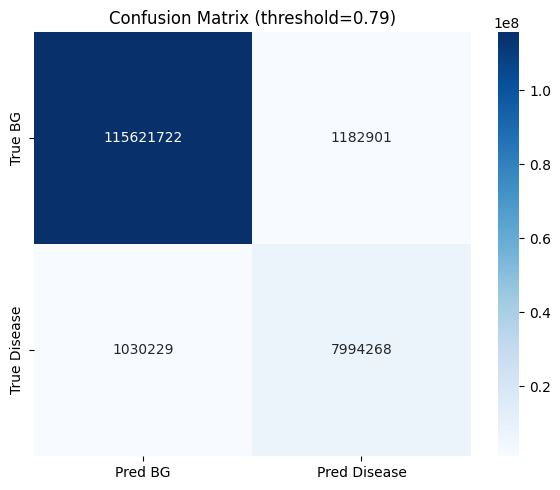

Results saved.


In [17]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Final metrics at best threshold
pb = (all_preds > best_thresh).float()
tp = (pb * all_masks).sum().item()
fp = (pb * (1 - all_masks)).sum().item()
fn = ((1 - pb) * all_masks).sum().item()
tn = ((1 - pb) * (1 - all_masks)).sum().item()

final = {
    'IoU':         round(tp / (tp + fp + fn + 1e-8), 4),
    'F1 / Dice':   round(2*tp / (2*tp + fp + fn + 1e-8), 4),
    'Precision':   round(tp / (tp + fp + 1e-8), 4),
    'Recall':      round(tp / (tp + fn + 1e-8), 4),
    'Specificity': round(tn / (tn + fp + 1e-8), 4),
    'Accuracy':    round((tp + tn) / (tp + tn + fp + fn + 1e-8), 4),
}

targets = {'IoU': 0.83, 'F1 / Dice': 0.90, 'Accuracy': 0.90, 'Specificity': 0.95}
print(f"\n=== Final Metrics (threshold={best_thresh}) ===")
for k, v in final.items():
    target = targets.get(k)
    status = f"→ {'PASS ✓' if target and v >= target else 'FAIL ✗' if target else ''}"
    print(f"  {k:14s}: {v:.4f}  {status}")

# Confusion matrix
cm = confusion_matrix(
    all_masks.numpy().flatten().astype(int),
    pb.numpy().flatten().astype(int)
)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Pred BG', 'Pred Disease'],
            yticklabels=['True BG', 'True Disease'])
plt.title(f'Confusion Matrix (threshold={best_thresh})')
plt.tight_layout()
plt.savefig('/content/confusion_matrix.png', dpi=150)
plt.show()

# Save results
import json
results = {
    'best_threshold': float(best_thresh),
    'final_metrics':  final,
    'history':        history
}
with open('/content/results.json', 'w') as f:
    json.dump(results, f, indent=2)
print("Results saved.")

Disease patches in val set: 124


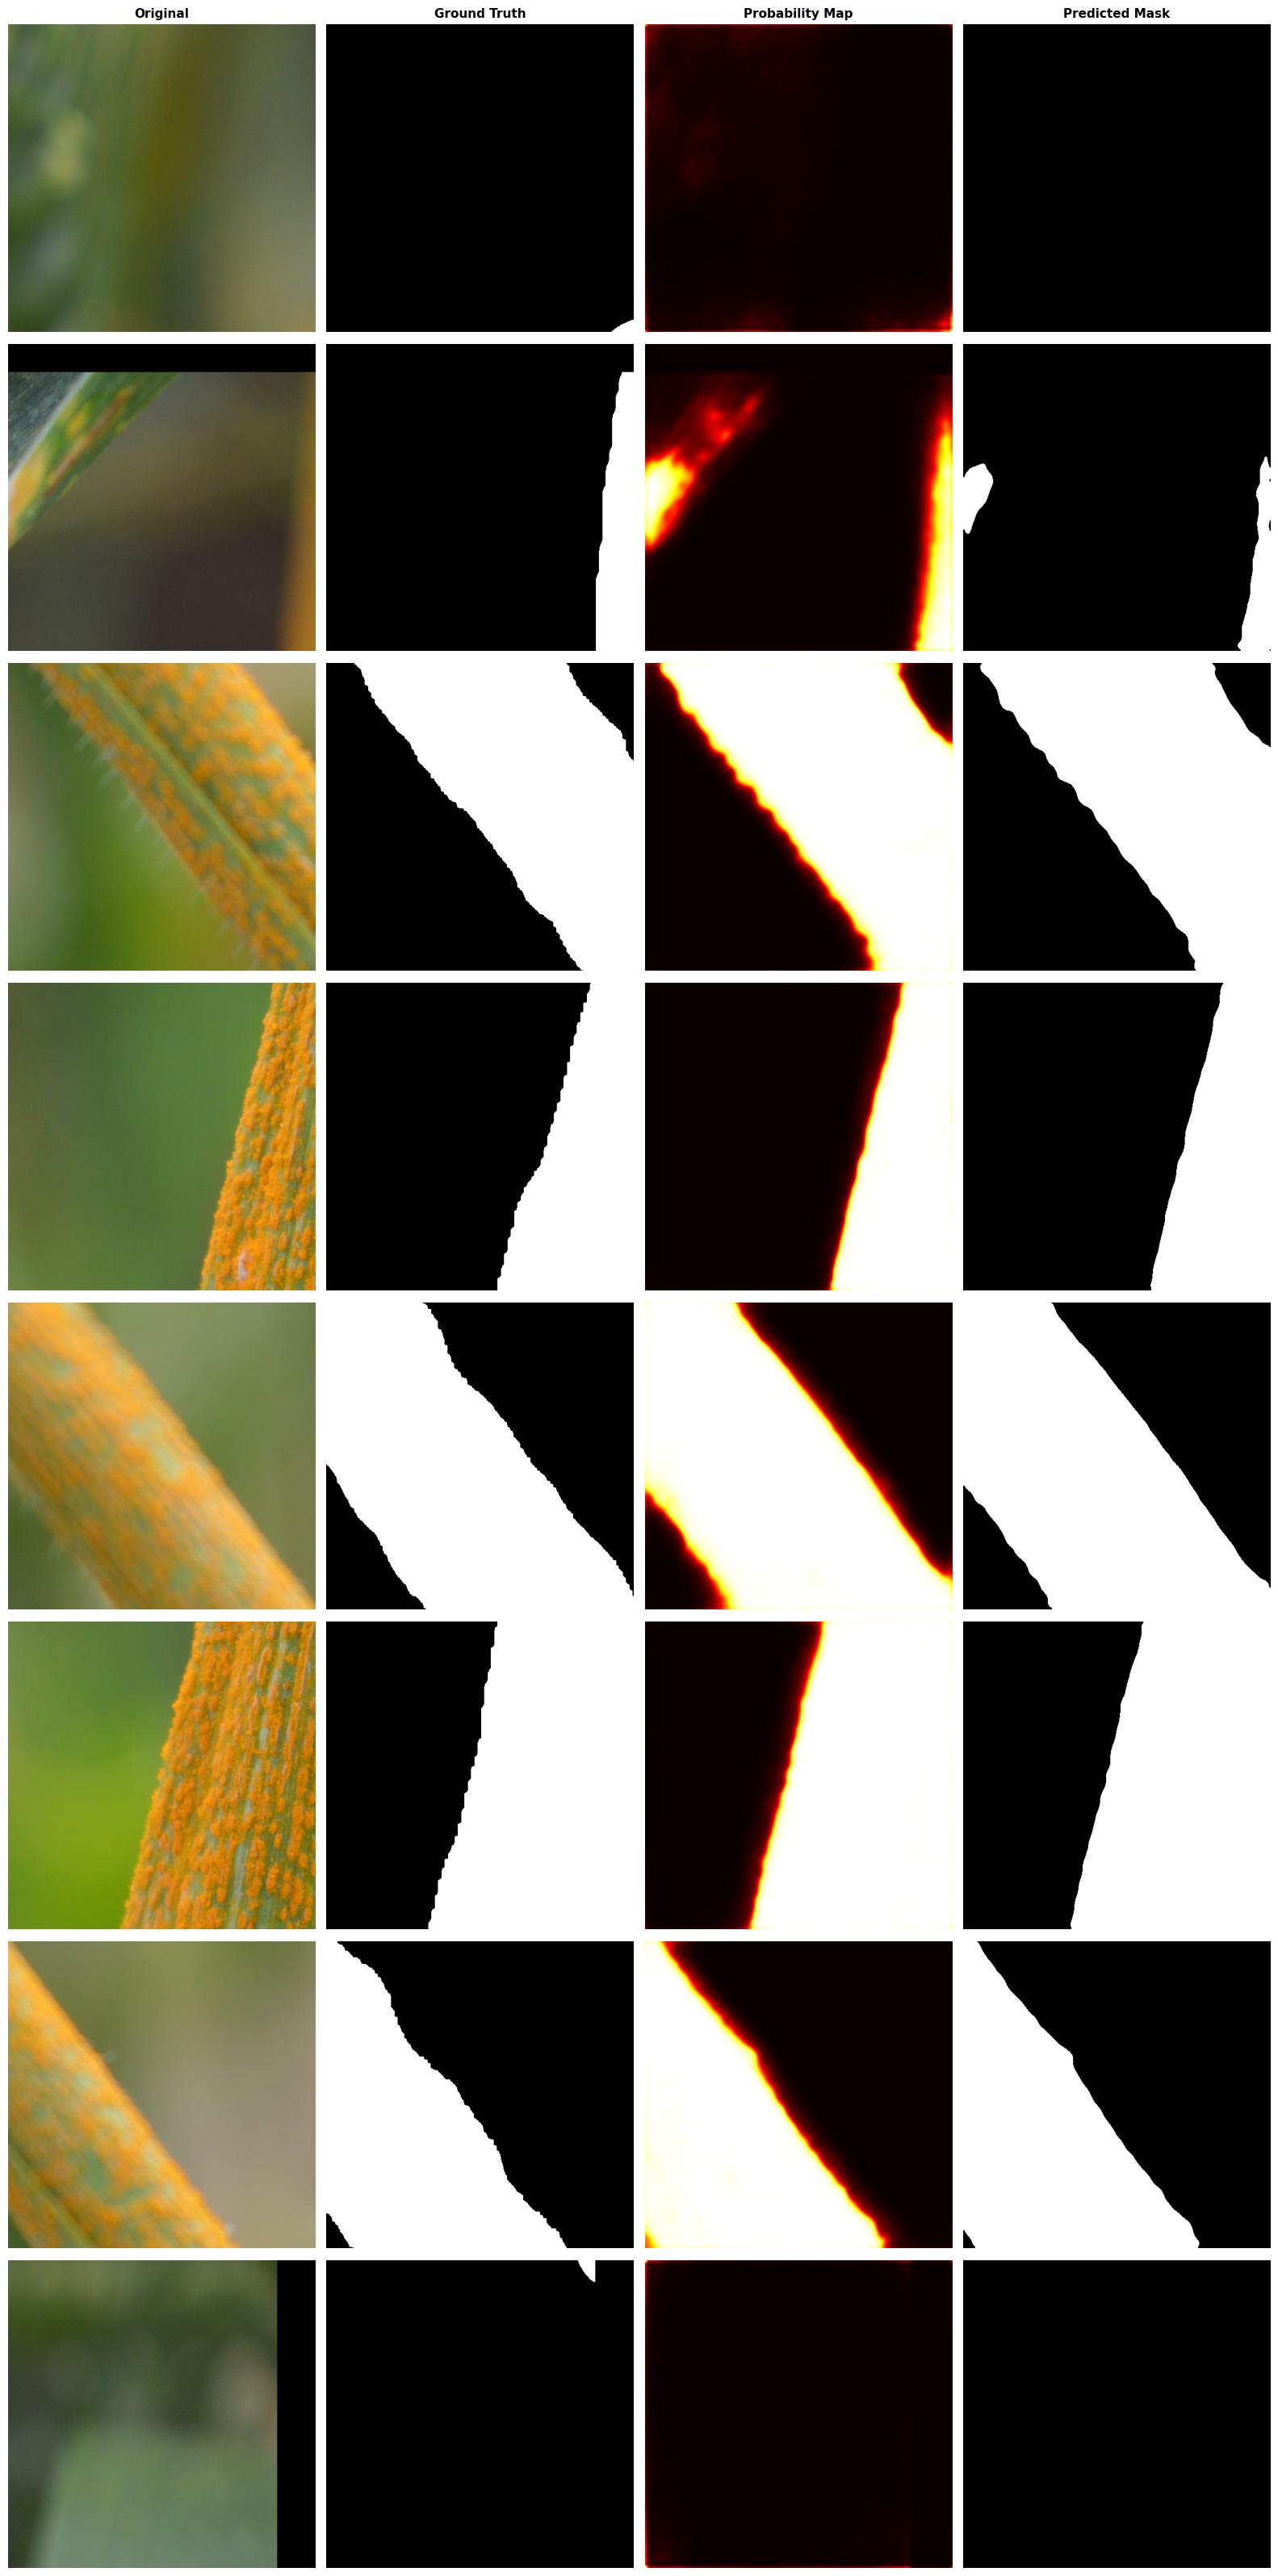

Qualitative results saved.


In [18]:
def denorm(t):
    m, s = [0.485, 0.456, 0.406], [0.229, 0.224, 0.225]
    t = t.clone()
    for i in range(3): t[i] = t[i] * s[i] + m[i]
    return t.clamp(0, 1)

# Filter val_dataset for disease-only patches
disease_indices = [
    i for i, f in enumerate(val_files)
    if analyze_mask(os.path.join(cfg.val_mask_dir, f)) > 0
]
print(f"Disease patches in val set: {len(disease_indices)}")

# Sample 8 random disease patches
sampled = random.sample(disease_indices, min(8, len(disease_indices)))
model.eval()

fig, axes = plt.subplots(len(sampled), 4, figsize=(16, 4 * len(sampled)))
cols = ['Original', 'Ground Truth', 'Probability Map', 'Predicted Mask']
for ax, col in zip(axes[0], cols):
    ax.set_title(col, fontsize=11, fontweight='bold')

for row, idx in enumerate(sampled):
    img, mask = val_ds[idx]
    with torch.no_grad():
        pred = torch.sigmoid(model(img.unsqueeze(0).to(device))).squeeze().cpu()

    axes[row][0].imshow(denorm(img).permute(1, 2, 0).numpy())
    axes[row][1].imshow(mask[0].numpy(), cmap='gray')
    axes[row][2].imshow(pred.numpy(), cmap='hot')
    axes[row][3].imshow((pred > best_thresh).numpy(), cmap='gray')
    for ax in axes[row]: ax.axis('off')

plt.tight_layout()
plt.savefig('/content/qualitative_results.png', dpi=150)
plt.show()
print("Qualitative results saved.")

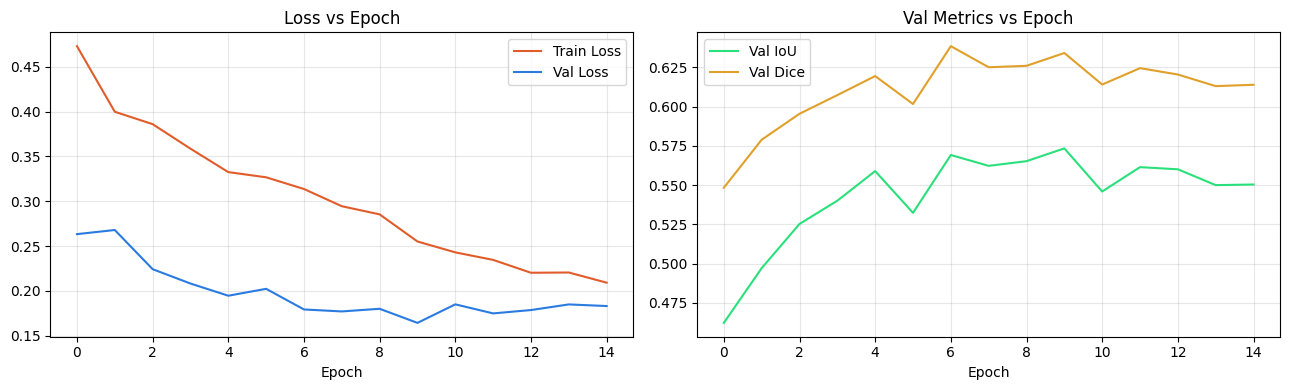

In [19]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
ax1.plot(history['train_loss'], label='Train Loss', color='#E05C2A')
ax1.plot(history['val_loss'],   label='Val Loss',   color='#2A7BE0')
ax1.set_title('Loss vs Epoch'); ax1.set_xlabel('Epoch'); ax1.legend()
ax1.grid(alpha=0.3)

ax2.plot(history['val_iou'],  label='Val IoU',  color='#2AE07B')
ax2.plot(history['val_dice'], label='Val Dice', color='#E0A02A')
ax2.set_title('Val Metrics vs Epoch'); ax2.set_xlabel('Epoch'); ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('/content/training_curves.png', dpi=150)
plt.show()